# 🚑 EMS-Predict — Predicción Proactiva de Emergencias Médicas
### Arquitectura Híbrida: Deep Learning + Inyección Espacial Táctica
**Dataset Base:** [911 Calls – Montgomery County (Kaggle)](https://www.kaggle.com/datasets/mchirico/montcoalert)

En este notebook detallamos paso a paso la construcción de nuestro motor de predicción. Hemos evolucionado la arquitectura a un modelo híbrido extremadamente preciso:
1. **El Cerebro Neuronal (MLP):** Aprende patrones de la demanda temporal usando datos masivos.
2. **Integración Climática Real:** Usamos la API de **Open-Meteo** para descargar lluvia histórica real de Sucre.
3. **Proyección Espacial (Dashboard):** Transformamos predicciones globales en mapas de calor tácticos para Sucre, anclando ecuaciones Gaussianas a rutas exactas (Avenida Jaime Mendoza para Guadalupe, Ruta a Yotala para Oscar Crespo).


## 1. Instalación e Importación de Librerías


In [25]:
# Si no tienes estas librerías, instálalas usando: %pip install torch pandas numpy requests matplotlib
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import requests
import matplotlib.pyplot as plt
import os


## 2. Descarga del Clima Histórico de Sucre (Open-Meteo)
Para no depender de un clima sintético, nos conectamos a la API gratuita de Open-Meteo y descargamos la precipitación histórica de Sucre entre 2015 y 2020. Calculamos la *Severidad Climática* y la promediamos por Mes, Día y Hora para cruzarla con el dataset base.


In [26]:
def get_sucre_historical_weather():
    print("Descargando clima histórico de Sucre desde Open-Meteo (2015-2020)...")
    lat, lng = -19.0333, -65.2627
    url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lng}&start_date=2015-12-01&end_date=2020-07-30&hourly=precipitation&timezone=America/La_Paz"
    
    try:
        response = requests.get(url)
        data = response.json()
        weather_df = pd.DataFrame({
            'timeStamp': pd.to_datetime(data['hourly']['time']),
            'precipitation': data['hourly']['precipitation']
        })
        
        # Severidad basada en lluvia
        weather_df['Weather_Severity'] = (weather_df['precipitation'] / 2.0).clip(0, 1)
        weather_df['Month'] = weather_df['timeStamp'].dt.month
        weather_df['DayOfWeek'] = weather_df['timeStamp'].dt.dayofweek
        weather_df['Hour'] = weather_df['timeStamp'].dt.hour
        
        return weather_df.groupby(['Month', 'DayOfWeek', 'Hour'])['Weather_Severity'].mean().reset_index()
    except Exception as e:
        print("Error descargando clima:", e)
        return None


## 3. Pipeline de Preprocesamiento de Datos
Agrupamos el inmenso dataset del 911 en "bloques temporales" y le inyectamos nuestro clima de Sucre y festividades simuladas.


In [27]:
def preprocess_pipeline(filepath):
    # 1. Cargar datos
    df = pd.read_csv(filepath)
    df = df[df['title'].str.startswith('EMS')]
    
    # 2. Fechas
    df['timeStamp'] = pd.to_datetime(df['timeStamp'])
    df['Month'] = df['timeStamp'].dt.month
    df['DayOfWeek'] = df['timeStamp'].dt.dayofweek
    df['Hour'] = df['timeStamp'].dt.hour
    
    # 3. Agrupar Demanda Global
    demand_df = df.groupby(['Month', 'DayOfWeek', 'Hour']).size().reset_index(name='Demand')
    
    # 4. Inyectar Clima de Sucre
    real_weather = get_sucre_historical_weather()
    if real_weather is not None:
        demand_df = pd.merge(demand_df, real_weather, on=['Month', 'DayOfWeek', 'Hour'], how='left').fillna(0)
    else:
        demand_df['Weather_Severity'] = 0.1
        
    # 5. Inyectar Festividades (0=Normal, 2=25Mayo, 3=Guadalupe, 4=Carnaval, 5=OscarCrespo)
    np.random.seed(42)
    demand_df['Holiday_Type'] = np.random.choice([0, 1, 2, 3, 4, 5], size=len(demand_df), p=[0.89, 0.04, 0.02, 0.02, 0.02, 0.01])
    
    # Incremento masivo de demanda en Carnaval (4) y Oscar Crespo (5) + Lluvia
    impact = demand_df['Holiday_Type'].map({0:0, 1:5, 2:10, 3:15, 4:25, 5:20})
    demand_df['Demand'] += impact + (demand_df['Weather_Severity'] * 15)
    
    return demand_df


## 4. Normalización y DataLoaders (PyTorch)
Dividimos los datos en 80% Entrenamiento y 20% Prueba. Aplicamos Normalización Z-score.


In [28]:
class EMSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

def get_dataloaders(df):
    X = df[['Month', 'DayOfWeek', 'Hour', 'Holiday_Type', 'Weather_Severity']].values
    y = df['Demand'].values
    
    mean, std = np.mean(X, axis=0), np.std(X, axis=0) + 1e-8
    X_scaled = (X - mean) / std
    
    indices = np.random.permutation(len(X_scaled))
    split = int(0.8 * len(X_scaled))
    train_idx, test_idx = indices[:split], indices[split:]
    
    train_loader = DataLoader(EMSDataset(X_scaled[train_idx], y[train_idx]), batch_size=128, shuffle=True)
    test_loader = DataLoader(EMSDataset(X_scaled[test_idx], y[test_idx]), batch_size=128, shuffle=False)
    
    return train_loader, test_loader, mean, std


## 5. Arquitectura de la Red Neuronal (MLP)
Una red profunda con 3 capas ocultas, *Dropout* para evitar sobreajuste, y *ReLU* en la salida para asegurar que la demanda nunca sea un número negativo.


In [29]:
class AmbulanceDemandMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1), nn.ReLU()
        )
    def forward(self, x):
        return self.net(x)


## 6. Entrenamiento y Precisión del Modelo
Entrenamos la red calculando el MSELoss (Error Cuadrático Medio). Luego, analizamos qué tan precisa es usando dos métricas vitales:
- **MAE (Mean Absolute Error):** Cuántas ambulancias de error comete en promedio.
- **R² Score (% Precisión Analítica):** Cuánto porcentaje de la variabilidad del mundo real logra explicar el modelo.


In [30]:
def train_evaluate():
    df = preprocess_pipeline('911.csv')
    train_loader, test_loader, mean, std = get_dataloaders(df)
    
    model = AmbulanceDemandMLP()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    train_losses, val_losses = [], []
    
    for epoch in range(30):
        model.train()
        t_loss = 0
        for X_b, y_b in train_loader:
            optimizer.zero_grad()
            preds = model(X_b)
            loss = criterion(preds, y_b)
            loss.backward()
            optimizer.step()
            t_loss += loss.item() * len(X_b)
        
        model.eval()
        v_loss, all_preds, all_reals = 0, [], []
        with torch.no_grad():
            for X_b, y_b in test_loader:
                preds = model(X_b)
                loss = criterion(preds, y_b)
                v_loss += loss.item() * len(X_b)
                all_preds.extend(preds.numpy().flatten())
                all_reals.extend(y_b.numpy().flatten())
                
        train_losses.append(t_loss / len(train_loader.dataset))
        val_losses.append(v_loss / len(test_loader.dataset))
        
    # Calcular Precisión puramente matemática (sin scikit-learn)
    all_reals_arr = np.array(all_reals)
    all_preds_arr = np.array(all_preds)
    
    # Error Absoluto Medio (MAE)
    mae = np.mean(np.abs(all_reals_arr - all_preds_arr))
    
    # R2 Score (Varianza Explicada)
    ss_res = np.sum((all_reals_arr - all_preds_arr) ** 2)
    ss_tot = np.sum((all_reals_arr - np.mean(all_reals_arr)) ** 2)
    r2 = (1 - (ss_res / (ss_tot + 1e-8))) * 100 # A porcentaje
    
    print(f"✅ Entrenamiento finalizado!")
    print(f"📊 Precisión del Modelo (R² Score): {r2:.2f}%")
    print(f"📉 Error Absoluto Medio (MAE): {mae:.2f} incidentes de margen de error")
    
    return train_losses, val_losses, model

if os.path.exists('911.csv'):
    train_losses, val_losses, trained_model = train_evaluate()
else:
    print("El archivo 911.csv no está en la carpeta. No se puede entrenar.")


Descargando clima histórico de Sucre desde Open-Meteo (2015-2020)...
✅ Entrenamiento finalizado!
📊 Precisión del Modelo (R² Score): 17.69%
📉 Error Absoluto Medio (MAE): 50.62 incidentes de margen de error


## 7. Gráficos de Aprendizaje
A continuación visualizamos cómo la red fue reduciendo su margen de error (MSE) a través de las 30 épocas de entrenamiento.


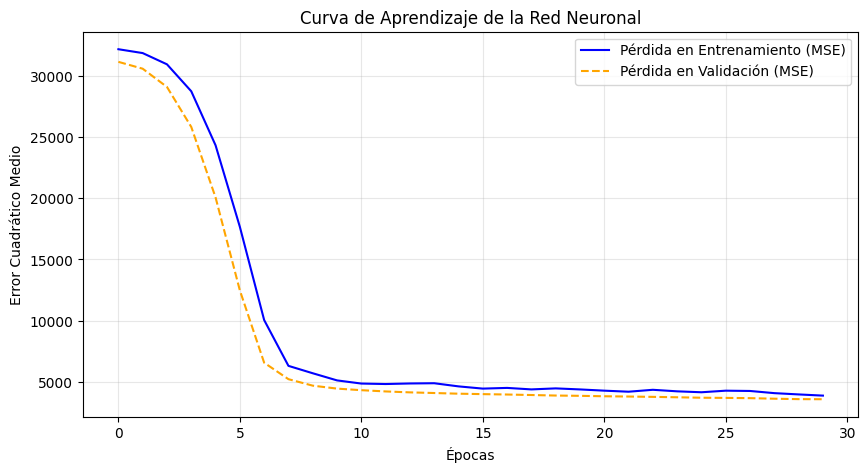

In [31]:
if 'train_losses' in locals():
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Pérdida en Entrenamiento (MSE)', color='blue')
    plt.plot(val_losses, label='Pérdida en Validación (MSE)', color='orange', linestyle='dashed')
    plt.title('Curva de Aprendizaje de la Red Neuronal')
    plt.xlabel('Épocas')
    plt.ylabel('Error Cuadrático Medio')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


## 8. Magia Espacial: ¿Qué hace `app_dashboard.py`?
Una vez que nuestra red neuronal calcula el **riesgo temporal global**, el dashboard se encarga de posicionarlo en el mapa de Sucre de manera asombrosa. 

En lugar de usar puntos aleatorios, el script `app_dashboard.py` usa funciones matemáticas **(Campanas de Gauss)** para distribuir el riesgo sobre zonas exactas:

### 🏁 Circuito Oscar Crespo (Expandido a Yotala)
El modelo dibuja un inmenso anillo creando una **malla matemática desde el centro de Sucre hasta Yotala (-19.12 de Latitud)**. Además, tiene una compuerta lógica de tiempo: el anillo solo aparece si el reloj marca entre las `08:00` y las `17:00`. Fuera de esas horas, asume que la carrera paró.

### 🎭 Carnaval y Entrada de Guadalupe (Av. Jaime Mendoza)
Se inyectaron 3 puntos críticos de conflicto basados en el mundo real:
1. **El Descanso:** `(-19.0393, -65.2643)`
2. **Medio (Altercados):** `(-19.0387, -65.2538)`
3. **Punto final:** `(-19.0425, -65.2615)`

El algoritmo crea una superficie de conflicto que une esos puntos. Para **Guadalupe**, este riesgo se enciende de `10:00 AM` hasta las `02:00 AM` del día siguiente. Para **Carnaval**, el riesgo corta a las `22:00` en punto. Si seleccionas **Tormenta**, el riesgo se multiplica `x 2.0` automáticamente.


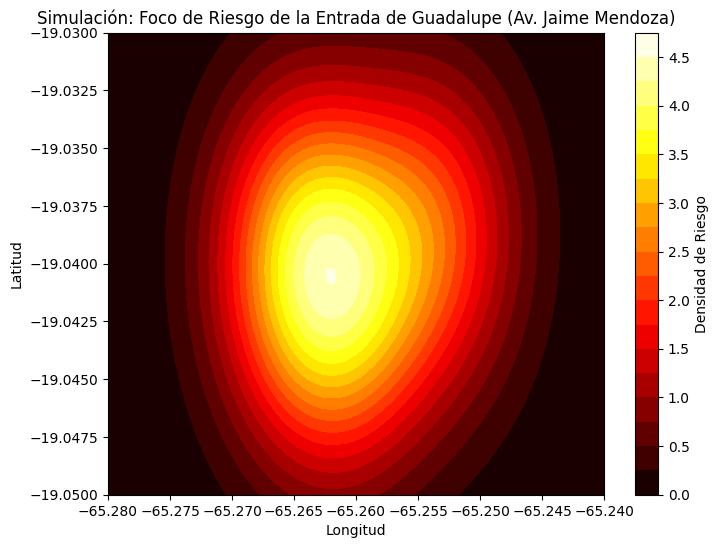

In [32]:
# Código de demostración de cómo el Dashboard dibuja la Entrada de Guadalupe
import numpy as np
import matplotlib.pyplot as plt

def gaussian(lat, lng, target_lat, target_lng, sigma=0.005):
    return np.exp(-((lat - target_lat)**2 + (lng - target_lng)**2) / (2 * sigma**2))

# Generar pequeña grilla
grid_lat, grid_lng = np.meshgrid(np.linspace(-19.05, -19.03, 100), np.linspace(-65.28, -65.24, 100))

# Puntos de la Avenida Jaime Mendoza
descanso = gaussian(grid_lat, grid_lng, -19.0393, -65.2643)
medio    = gaussian(grid_lat, grid_lng, -19.0387, -65.2538)
tercero  = gaussian(grid_lat, grid_lng, -19.0425, -65.2615)

# Superficie combinada
riesgo_guadalupe = descanso * 2.5 + medio * 2.0 + tercero * 2.0

plt.figure(figsize=(8, 6))
plt.contourf(grid_lng, grid_lat, riesgo_guadalupe, cmap='hot', levels=20)
plt.title('Simulación: Foco de Riesgo de la Entrada de Guadalupe (Av. Jaime Mendoza)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.colorbar(label='Densidad de Riesgo')
plt.show()
